# Aspect-Based Sentiment Analysis on Restaurant Reviews

Fine-tuning DistilBERT for aspect-level sentiment classification on the SemEval-2014 Task 4 dataset, compared against rule-based and TF-IDF baselines.




In [6]:
# Install dependencies
!pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn

In [7]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
if device.type == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")

device: cuda
gpu: Tesla T4


## 1. Data

We use the SemEval-2014 Task 4 restaurant reviews subset (Pontiki et al., 2014). The HuggingFace mirror by **tomaarsen** provides the data in the modern parquet format with **text**, **span**, and **label** fields, where **span** is the aspect term and **label** is the sentiment toward that aspect.

In [8]:
dataset = load_dataset("tomaarsen/setfit-absa-semeval-restaurants")
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"train: {len(train_df)} | test: {len(test_df)}")
print(f"columns: {list(train_df.columns)}")
train_df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/147k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/46.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3693 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1134 [00:00<?, ? examples/s]

train: 3693 | test: 1134
columns: ['text', 'span', 'label', 'ordinal']


,text,span,label,ordinal
0,But the staff was so horrible to us.,staff,negative,0
1,"To be completely fair, the only redeeming fact...",food,positive,0
2,"The food is uniformly exceptional, with a very...",food,positive,0


In [9]:
# Inspect labels - the test split has empty labels (intended for held-out evaluation
# in the original shared task), so I will create our own test split from the training data.
print("train label counts:")
print(train_df['label'].value_counts())
print(f"\ntest label uniques: {test_df['label'].unique()}")

train label counts:
label
positive    2164
negative     805
neutral      633
conflict      91
Name: count, dtype: int64

test label uniques: ['']


### Filtering

The 'conflict' class has only 91 examples and is dropped, following standard practice in ABSA literature (Tang et al., 2016; Sun et al., 2019). We keep the three main polarities: positive, neutral, negative.

In [10]:
KEEP_LABELS = ['positive', 'neutral', 'negative']
df = train_df[train_df['label'].isin(KEEP_LABELS)].reset_index(drop=True)
print(f"after filtering: {len(df)} (dropped {len(train_df) - len(df)})")
print(df['label'].value_counts(normalize=True).round(3))

after filtering: 3602 (dropped 91)
label
positive    0.601
negative    0.223
neutral     0.176
Name: proportion, dtype: float64


### Exploratory data analysis

In [11]:
# Length distribution and sentiment balance
df['n_tokens'] = df['text'].str.split().str.len()

print(df['n_tokens'].describe().round(1))
print(f"\nunique aspect terms: {df['span'].nunique()}")
print("\ntop aspects:")
print(df['span'].value_counts().head(10))

count    3602.0
mean       17.5
std         9.3
min         1.0
25%        11.0
50%        16.0
75%        22.0
max        69.0
Name: n_tokens, dtype: float64

unique aspect terms: 1268

top aspects:
span
food          345
service       197
place          59
prices         58
dinner         55
menu           55
staff          54
atmosphere     46
pizza          43
table          41
Name: count, dtype: int64


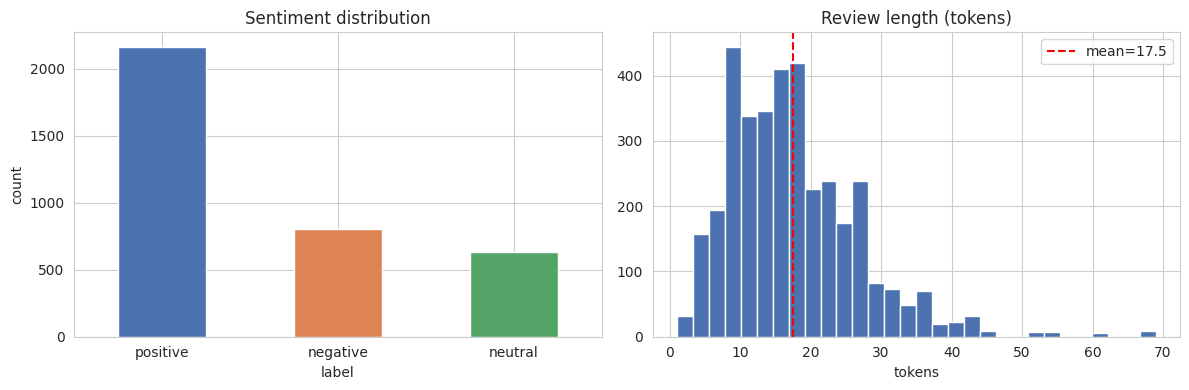

In [12]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=ax[0], color=['#4c72b0', '#dd8452', '#55a467'])
ax[0].set_title('Sentiment distribution')
ax[0].set_ylabel('count')
ax[0].tick_params(axis='x', rotation=0)

ax[1].hist(df['n_tokens'], bins=30, color='#4c72b0', edgecolor='white')
ax[1].axvline(df['n_tokens'].mean(), color='red', linestyle='--', label=f"mean={df['n_tokens'].mean():.1f}")
ax[1].set_title('Review length (tokens)')
ax[1].set_xlabel('tokens')
ax[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

### Train/val/test split

Stratified 70/15/15 split. Validation is used for early stopping during DistilBERT training; test is held out for final evaluation.

In [13]:
# Two-step split: first carve out 15% test, then split remainder 70/15
df_clean = df.drop(columns=['n_tokens'])

train_val, test = train_test_split(
    df_clean, test_size=0.15, stratify=df_clean['label'], random_state=SEED
)
train, val = train_test_split(
    train_val, test_size=0.176, stratify=train_val['label'], random_state=SEED
)

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"train: {len(train)} | val: {len(val)} | test: {len(test)}")
print("\nlabel proportions per split:")
for name, split in [('train', train), ('val', val), ('test', test)]:
    props = split['label'].value_counts(normalize=True).round(3).to_dict()
    print(f"  {name}: {props}")

train: 2522 | val: 539 | test: 541

label proportions per split:
  train: {'positive': 0.601, 'negative': 0.224, 'neutral': 0.176}
  val: {'positive': 0.601, 'negative': 0.223, 'neutral': 0.176}
  test: {'positive': 0.601, 'negative': 0.224, 'neutral': 0.176}


## 2. Baseline 1: Lexicon-based sentiment

Counts hand-curated positive and negative sentiment words in the review and predicts the majority polarity. This represents the pre-deep-learning approach to sentiment analysis (Hu & Liu, 2004) and serves as a sanity-check floor.

In [14]:
POS_LEX = {
    'good', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic', 'love',
    'best', 'perfect', 'delicious', 'tasty', 'fresh', 'friendly', 'nice',
    'awesome', 'outstanding', 'superb', 'enjoyable', 'pleasant', 'recommend',
    'favorite', 'beautiful'
}
NEG_LEX = {
    'bad', 'terrible', 'awful', 'horrible', 'worst', 'poor', 'disappointing',
    'rude', 'slow', 'cold', 'stale', 'overpriced', 'dirty', 'nasty', 'gross',
    'mediocre', 'bland', 'tough', 'unfriendly', 'avoid', 'never', 'waste'
}

def lexicon_predict(text):
    tokens = [t.strip('.,!?;:') for t in text.lower().split()]
    pos = sum(1 for t in tokens if t in POS_LEX)
    neg = sum(1 for t in tokens if t in NEG_LEX)
    if pos > neg: return 'positive'
    if neg > pos: return 'negative'
    return 'neutral'

y_test = test['label'].tolist()
y_pred_lex = [lexicon_predict(t) for t in test['text']]

acc_lex = accuracy_score(y_test, y_pred_lex)
p_lex, r_lex, f1_lex, _ = precision_recall_fscore_support(
    y_test, y_pred_lex, average='macro', zero_division=0
)
print(f"lexicon baseline | acc={acc_lex:.4f}  f1={f1_lex:.4f}")
print(classification_report(y_test, y_pred_lex, zero_division=0))

lexicon baseline | acc=0.5194  f1=0.4562
              precision    recall  f1-score   support

    negative       0.63      0.21      0.32       121
     neutral       0.26      0.73      0.38        95
    positive       0.79      0.57      0.66       325

    accuracy                           0.52       541
   macro avg       0.56      0.50      0.46       541
weighted avg       0.66      0.52      0.54       541



## 3. Baseline 2: TF-IDF + Logistic Regression

A standard linear baseline. The aspect span is prepended to the review text so the classifier can condition on which aspect we are scoring. Class weights are balanced because of the positive-class skew.

In [15]:
def fmt(df_):
    # Concatenate aspect and text so the model sees the target aspect
    return (df_['span'].astype(str) + ' [SEP] ' + df_['text'].astype(str)).tolist()

X_train = fmt(train)
X_test = fmt(test)
y_train = train['label'].tolist()

tfidf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95,
                              max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                random_state=SEED))
])

tfidf_pipe.fit(X_train, y_train)
y_pred_tfidf = tfidf_pipe.predict(X_test)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
p_tfidf, r_tfidf, f1_tfidf, _ = precision_recall_fscore_support(
    y_test, y_pred_tfidf, average='macro', zero_division=0
)
print(f"tfidf+lr | acc={acc_tfidf:.4f}  f1={f1_tfidf:.4f}")
print(classification_report(y_test, y_pred_tfidf, zero_division=0))

tfidf+lr | acc=0.6784  f1=0.6191
              precision    recall  f1-score   support

    negative       0.52      0.56      0.54       121
     neutral       0.48      0.60      0.53        95
    positive       0.83      0.74      0.79       325

    accuracy                           0.68       541
   macro avg       0.61      0.64      0.62       541
weighted avg       0.70      0.68      0.69       541



## 4. Fine-tuned DistilBERT

We fine-tune **distilbert-base-uncased** (Sanh et al., 2019) on the (aspect, review) pairs. DistilBERT retains ~97% of BERT-base's GLUE performance while being 40% smaller and 60% faster, which fits the free-Colab constraint.

**Input format:** **[CLS] aspect [SEP] review [SEP]** — the standard sentence-pair format used in BERT-style ABSA work (Sun et al., 2019).

**Loss:** weighted cross-entropy with inverse-frequency class weights to counter the positive-class skew.

**Hyperparameters** follow the BERT fine-tuning recipe (Devlin et al., 2019): lr=2e-5, batch=16, AdamW with weight decay 0.01, linear warmup over 10% of steps. We train for up to 6 epochs with early stopping (patience=2) on validation macro-F1.

In [16]:
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from torch.nn import CrossEntropyLoss

MODEL = "distilbert-base-uncased"
LABELS = ['negative', 'neutral', 'positive']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}

tokenizer = DistilBertTokenizer.from_pretrained(MODEL)

def to_dataset(df_):
    df_ = df_.copy()
    df_['labels'] = df_['label'].map(label2id)
    return Dataset.from_pandas(df_[['text', 'span', 'labels']], preserve_index=False)

def tokenize(batch):
    return tokenizer(batch['span'], batch['text'],
                     truncation=True, padding='max_length', max_length=128)

train_ds = to_dataset(train).map(tokenize, batched=True)
val_ds = to_dataset(val).map(tokenize, batched=True)
test_ds = to_dataset(test).map(tokenize, batched=True)

cols = ['input_ids', 'attention_mask', 'labels']
for ds in (train_ds, val_ds, test_ds):
    ds.set_format('torch', columns=cols)

print(f"tokenized | train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2522 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Map:   0%|          | 0/541 [00:00<?, ? examples/s]

tokenized | train=2522 val=539 test=541


In [17]:
# Inverse-frequency class weights from training set
y_train_int = train['label'].map(label2id).values
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train_int)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("class weights (neg, neu, pos):", class_weights.round(3))

class weights (neg, neu, pos): [1.491 1.898 0.555]


In [18]:
class WeightedTrainer(Trainer):
    """Trainer with weighted cross-entropy to handle class imbalance."""
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(outputs.logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1, 'precision': p, 'recall': r}

In [19]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL, num_labels=3, id2label=id2label, label2id=label2id
).to(device)

args = TrainingArguments(
    output_dir='./out',
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    report_to='none',
    seed=SEED,
    fp16=True,
    save_total_limit=2,
)

trainer = WeightedTrainer(
    class_weights=weights_tensor,
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.061228,0.782601,0.740260,0.669076,0.668858,0.672661
2,0.685928,0.724819,0.773655,0.711623,0.703579,0.722374
3,0.544698,0.770069,0.768089,0.711661,0.710725,0.717408
4,0.377652,0.784716,0.771800,0.715207,0.707479,0.726749
5,0.283766,0.801573,0.777365,0.723953,0.716522,0.739755
6,0.215330,0.847185,0.799629,0.734642,0.729301,0.740719


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=948, training_loss=0.5056157102061727, metrics={'train_runtime': 105.695, 'train_samples_per_second': 143.167, 'train_steps_per_second': 8.969, 'total_flos': 501133105953792.0, 'train_loss': 0.5056157102061727, 'epoch': 6.0})

## 5. Evaluation

In [20]:
# Predictions on held-out test set
preds = trainer.predict(test_ds)
y_pred_int = np.argmax(preds.predictions, axis=1)
y_pred_bert = [id2label[i] for i in y_pred_int]

acc_bert = accuracy_score(y_test, y_pred_bert)
p_bert, r_bert, f1_bert, _ = precision_recall_fscore_support(
    y_test, y_pred_bert, average='macro', zero_division=0
)
print(f"distilbert | acc={acc_bert:.4f}  f1={f1_bert:.4f}")
print(classification_report(y_test, y_pred_bert, zero_division=0))

distilbert | acc=0.7652  f1=0.6971
              precision    recall  f1-score   support

    negative       0.65      0.63      0.64       121
     neutral       0.54      0.63      0.58        95
    positive       0.89      0.86      0.87       325

    accuracy                           0.77       541
   macro avg       0.69      0.71      0.70       541
weighted avg       0.77      0.77      0.77       541



In [21]:
# Aggregate results table
results = pd.DataFrame([
    {'model': 'lexicon',     'accuracy': acc_lex,   'precision': p_lex,   'recall': r_lex,   'f1': f1_lex},
    {'model': 'tfidf+lr',    'accuracy': acc_tfidf, 'precision': p_tfidf, 'recall': r_tfidf, 'f1': f1_tfidf},
    {'model': 'distilbert',  'accuracy': acc_bert,  'precision': p_bert,  'recall': r_bert,  'f1': f1_bert},
]).set_index('model').round(4)

print(results)
results.to_csv('results.csv')

            accuracy  precision  recall      f1
model                                          
lexicon       0.5194     0.5620  0.5045  0.4562
tfidf+lr      0.6784     0.6095  0.6355  0.6191
distilbert    0.7652     0.6921  0.7050  0.6971


## 6. Visualizations

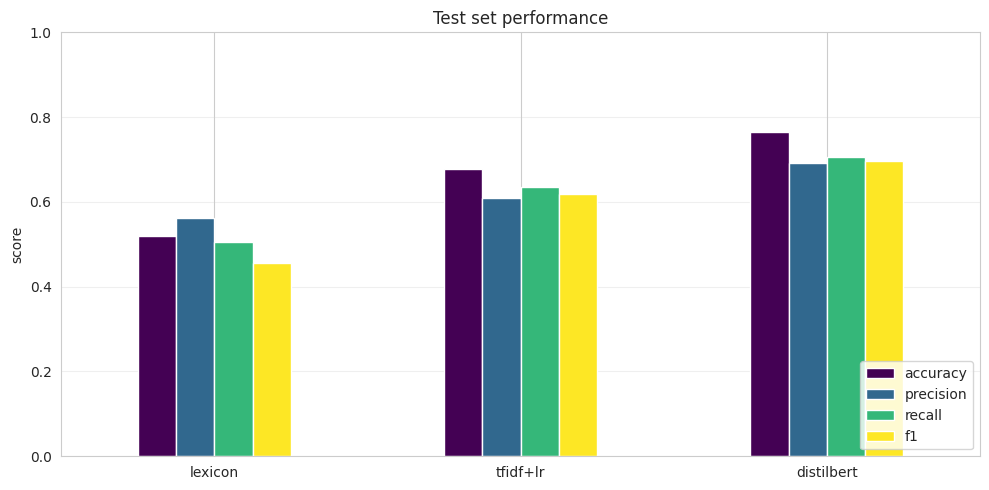

In [22]:
# Headline comparison
fig, ax = plt.subplots(figsize=(10, 5))
results.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Test set performance')
ax.set_ylabel('score')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

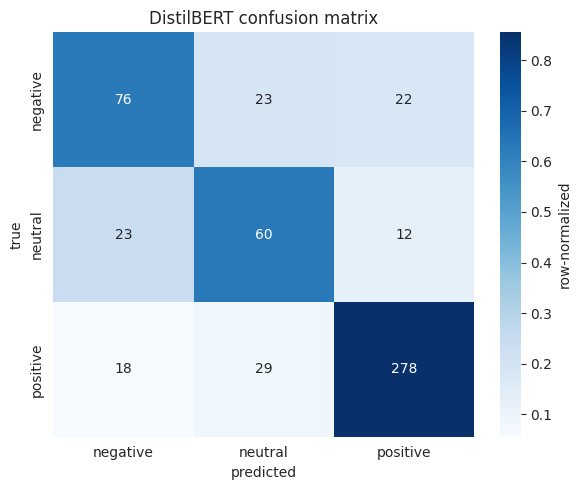

In [23]:
# Confusion matrix (DistilBERT)
cm = confusion_matrix(y_test, y_pred_bert, labels=LABELS)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            cbar_kws={'label': 'row-normalized'})
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('DistilBERT confusion matrix')
plt.tight_layout()
plt.savefig('confusion.png', dpi=150, bbox_inches='tight')
plt.show()

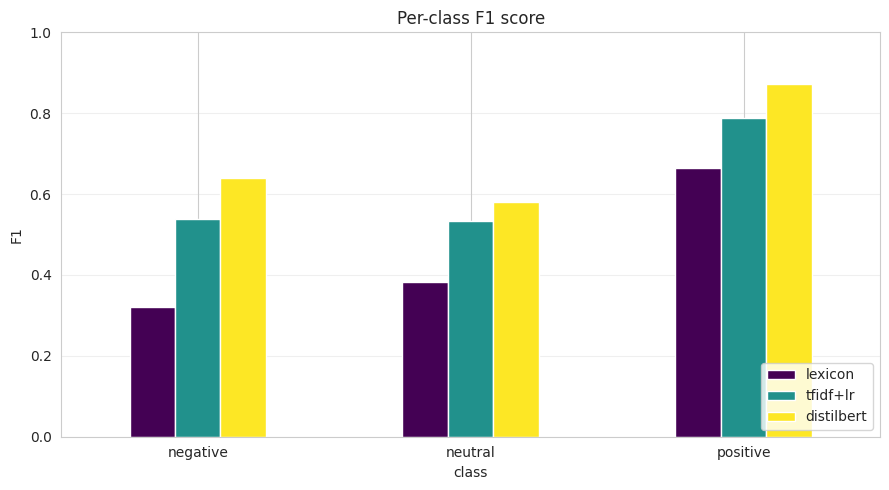

          lexicon  tfidf+lr  distilbert
negative    0.321     0.538       0.639
neutral     0.383     0.533       0.580
positive    0.664     0.787       0.873


In [24]:
# Per-class F1
def per_class(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=LABELS, average=None, zero_division=0)

per_class_df = pd.DataFrame({
    'lexicon':    per_class(y_test, y_pred_lex),
    'tfidf+lr':   per_class(y_test, y_pred_tfidf),
    'distilbert': per_class(y_test, y_pred_bert),
}, index=LABELS)

fig, ax = plt.subplots(figsize=(9, 5))
per_class_df.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Per-class F1 score')
ax.set_ylabel('F1')
ax.set_xlabel('class')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(per_class_df.round(3))

## 7. Error analysis

Looking at where the model fails reveals what kinds of linguistic phenomena remain hard. The dominant error patterns map back to the three challenges discussed in the report.

In [25]:
err = test.copy().reset_index(drop=True)
err['pred'] = y_pred_bert
err['correct'] = err['label'] == err['pred']
err['type'] = err['label'] + ' -> ' + err['pred']

errors_only = err[~err['correct']]
print(f"errors: {len(errors_only)} / {len(err)} ({len(errors_only)/len(err):.1%})")
print("\nerror type frequency:")
print(errors_only['type'].value_counts())

# Save for inspection
errors_only[['text', 'span', 'label', 'pred']].to_csv('errors.csv', index=False)

errors: 127 / 541 (23.5%)

error type frequency:
type
positive -> neutral     29
negative -> neutral     23
neutral -> negative     23
negative -> positive    22
positive -> negative    18
neutral -> positive     12
Name: count, dtype: int64


In [29]:
# Sample 2 examples from each of the top-3 error types
top3 = errors_only['type'].value_counts().head(3).index
for t in top3:
    print(f"\n {t} ")
    sample = errors_only[errors_only['type'] == t].head(2)
    for _, r in sample.iterrows():
        print(f"  aspect: {r['span']}")
        print(f"  text:   {r['text']}")
        print()


 positive -> neutral 
  aspect: capex
  text:   While they keep the capex to a minimum, they do put some cash into the bagels, because they among the best in the city.

  aspect: ingredients
  text:   Overall, the ingredients and technique are there and I am encouraged enough to return at lunch or dinner to see whether the boldness of the flavour palette improves.


 negative -> neutral 
  aspect: thai food
  text:   Don't eat here unless you're starving for thai food and you work next door.

  aspect: seasoning
  text:   Really though, where's the seasoning?


 neutral -> negative 
  aspect: bar
  text:   Yes you have to wait to be seated and because its small there is no waiting area and the seat at the bar was all taken.

  aspect: Chinese food
  text:   If your favorite Chinese food is General Tao chicken, then this is NOT your place.



## 8. Save artifacts

In [27]:
import json

# Persist the final model + tokenizer
trainer.save_model('./model')
tokenizer.save_pretrained('./model')

# JSON results dump
metadata = {
    'dataset': 'SemEval-2014 Task 4 (restaurants)',
    'source': 'tomaarsen/setfit-absa-semeval-restaurants',
    'splits': {'train': len(train), 'val': len(val), 'test': len(test)},
    'model': MODEL,
    'epochs': 6,
    'batch_size': 16,
    'lr': 2e-5,
    'class_weights': class_weights.tolist(),
    'seed': SEED,
}

output = {
    'metadata': metadata,
    'results': results.to_dict(),
    'per_class_f1': per_class_df.to_dict(),
}

with open('results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("saved: model/, results.csv, results.json, errors.csv, comparison.png, confusion.png, per_class_f1.png, eda.png")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: model/, results.csv, results.json, errors.csv, comparison.png, confusion.png, per_class_f1.png, eda.png


In [28]:
import shutil, os
from google.colab import files

files_to_zip = [
    'results.csv', 'results.json', 'errors.csv',
    'eda.png', 'comparison.png', 'confusion.png', 'per_class_f1.png',
]

# Folder for the zip
os.makedirs('absa_outputs', exist_ok=True)
for f in files_to_zip:
    if os.path.exists(f):
        shutil.copy(f, 'absa_outputs/')

shutil.make_archive('absa_outputs', 'zip', 'absa_outputs')
files.download('absa_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## References

- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL.
- Hu & Liu (2004). *Mining and Summarizing Customer Reviews.* KDD.
- Pontiki et al. (2014). *SemEval-2014 Task 4: Aspect Based Sentiment Analysis.* SemEval.
- Sanh et al. (2019). *DistilBERT, a distilled version of BERT.* arXiv:1910.01108.
- Sun et al. (2019). *Utilizing BERT for Aspect-Based Sentiment Analysis via Constructing Auxiliary Sentence.* NAACL.